In [1]:
!pip install pandas numpy scikit-learn joblib

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


Load Dataset

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data Cleaning





In [5]:
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

Features & Target

In [6]:
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No":0,
    "Yes":1
})

Identify Numeric & Categorical Columns

In [7]:
numeric_features = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

Preprocessing

In [8]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Categorical

In [9]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [10]:
preprocessor = ColumnTransformer([
    ("num",
     numeric_transformer,
     numeric_features),

    ("cat",
     categorical_transformer,
     categorical_features)
])

Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Logistic Regression Pipeline

In [12]:
log_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier",
     LogisticRegression(max_iter=1000))
])

Random Forest Pipeline

In [13]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("classifier",
     RandomForestClassifier(
         random_state=42
     ))
])

Hyperparameter Tuning

In [14]:
log_param_grid = {
    "classifier__C":[0.01,0.1,1,10]
}

In [15]:
log_grid = GridSearchCV(
    log_pipeline,
    log_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

log_grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('e...
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1, param_grid={'classifier__C': [0.01, 0.1, 1, 10]},
             scoring='accuracy')

Random Forest

In [16]:
rf_param_grid = {

    "classifier__n_estimators":[100,200],

    "classifier__max_depth":[5,10,None]
}

In [17]:
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('e...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy')

Compare Models

In [22]:
print(
    "Logistic Accuracy:",
    log_grid.best_score_
)

print(
    "Random Forest Accuracy:",
    rf_grid.best_score_
)

Logistic Accuracy: 0.8054668086616968
Random Forest Accuracy: 0.801384451544196


Select Best Model

In [18]:
if rf_grid.best_score_ > log_grid.best_score_:

    best_model = rf_grid.best_estimator_

else:

    best_model = log_grid.best_estimator_

results

In [19]:
y_pred = best_model.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.7991483321504613
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



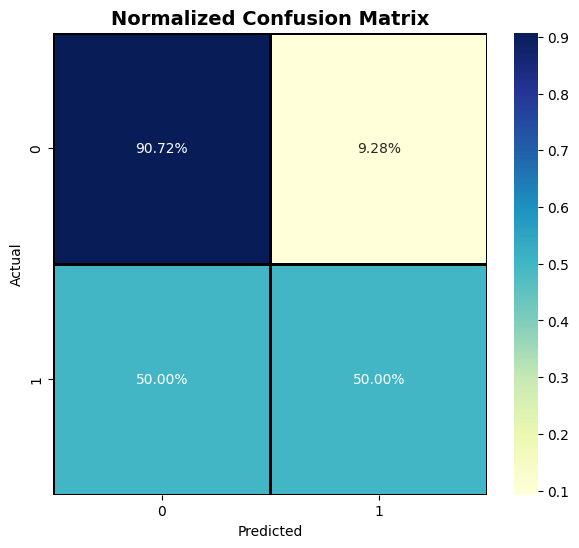

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2%',
    cmap='YlGnBu',
    linewidths=1,
    linecolor='black'
)

plt.title(
    'Normalized Confusion Matrix',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [20]:
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[939  96]
 [187 187]]
